1/1 [==============================] - 1s 997ms/step
Raw Predictions: [[0.05302953 0.79854214 0.14412723 0.00189812 0.00240288]]
Decoded Predictions: [[('common_krait', 0.79854214)]]


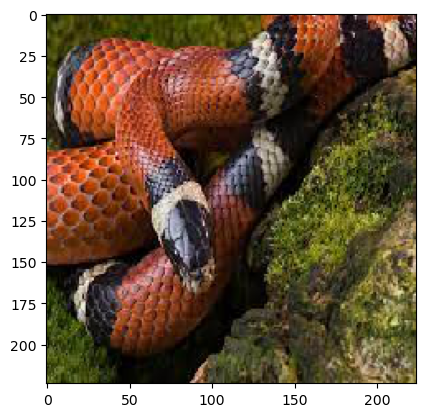

In [7]:
import keras
import numpy as np
from keras.applications import resnet50
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import load_model
import matplotlib.pyplot as plt

def decode_predictions_specific(preds, top=1, class_list=None):
    results = []
    for pred in preds:
        top_indices = pred.argsort()[-top:][::-1]
        result = [(class_list[i], pred[i]) for i in top_indices]
        results.append(result)
    return results

def predict_with_resnet50(image_path):
    model = load_model('resnet50-ft.model')

    # Load and preprocess the image
    original = load_img(image_path, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)
    processed_image = resnet50.preprocess_input(image_batch.copy())

    # Make predictions
    predictions = model.predict(processed_image)
    print('Raw Predictions:', predictions)

    # Decode predictions (get the class labels)
    class_list = ["cobra", "common_krait", "hump_nosed_pit_viper", "russells_viper", "Saw_Scaled_Viper"]
    decoded_predictions = decode_predictions_specific(predictions, top=1, class_list=class_list)
    print('Decoded Predictions:', decoded_predictions)

    # Display the image
    plt.imshow(original)
    plt.show()

# Example usage
image_path = "2.jpg"
predict_with_resnet50(image_path)
